# Dataset

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", path)

100%|██████████| 429M/429M [00:11<00:00, 40.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1


In [2]:
# Use this when no signal.
# path = "/home/master/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1"

```text
This portion of the RAVDESS contains 1440 files: 60 trials per actor x 24 actors = 1440. The RAVDESS contains 24 professional actors (12 female, 12 male), vocalizing two lexically-matched statements in a neutral North American accent. Speech emotions includes calm, happy, sad, angry, fearful, surprise, and disgust expressions. Each expression is produced at two levels of emotional intensity (normal, strong), with an additional neutral expression.

Emotions: calm, happy, sad, angry, fearful, surprise, disgust
```

File naming convention:

- Modality (01 = full-AV, 02 = video-only, 03 = audio-only) - **don't care we only have audio**

- Vocal channel (01 = speech, 02 = song)  - **don't care we only have speech**

- **Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).**

- Emotional intensity (01 = normal, 02 = strong). NOTE: **There is no strong intensity for the 'neutral' emotion.**

- Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").

- Repetition (01 = 1st repetition, 02 = 2nd repetition) - **Related to intensity I think**

- Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

Filename example: 03-01-06-01-02-01-12.wav

    Audio-only (03)
    Speech (01)
    Fearful (06)
    Normal intensity (01)
    Statement "dogs" (02)
    1st Repetition (01)
    12th Actor (12)
    Female, as the actor ID number is even.


In [9]:
from pathlib import Path
import os

In [10]:
# Actors
ds_path = Path(path)
ds_path = Path(path+"/audio_speech_actors_01-24")
os.listdir(ds_path)

['Actor_04',
 'Actor_09',
 'Actor_23',
 'Actor_18',
 'Actor_12',
 'Actor_24',
 'Actor_14',
 'Actor_21',
 'Actor_05',
 'Actor_13',
 'Actor_06',
 'Actor_17',
 'Actor_15',
 'Actor_07',
 'Actor_19',
 'Actor_11',
 'Actor_20',
 'Actor_10',
 'Actor_02',
 'Actor_16',
 'Actor_22',
 'Actor_03',
 'Actor_08',
 'Actor_01']

In [11]:
# Actor audio files
os.listdir(os.path.join(ds_path, "Actor_03"))[:5]

['03-01-04-02-01-01-03.wav',
 '03-01-07-01-02-01-03.wav',
 '03-01-04-01-02-01-03.wav',
 '03-01-03-02-01-02-03.wav',
 '03-01-04-01-01-01-03.wav']

In [12]:
audio_sample = Path(os.path.join(ds_path, "Actor_01/03-01-02-02-01-02-01.wav"))
audio_sample

PosixPath('/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/audio_speech_actors_01-24/Actor_01/03-01-02-02-01-02-01.wav')

In [13]:
%%capture
# Grab all audio filepaths

audio_paths = [str(p) for p in ds_path.rglob("*") if p.is_file()]
audio_paths

In [14]:
audio_paths[0]

'/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/audio_speech_actors_01-24/Actor_04/03-01-03-01-02-01-04.wav'

In [15]:
len(audio_paths)

1440

In [16]:
%%capture
# Grab emotions labels per audio

emotion_labels = [ int(f.split("/")[-1].split("-")[2]) - 1 for f in audio_paths ]

In [189]:
set(emotion_labels)

{0, 1, 2, 3, 4, 5, 6, 7}

Emotion labels:

0: Neutral

1: Calm

2: Happy

3: Sad

4: Angry

5: Fearful

6: Disgust

7: Surprised

---

# Spectrograms

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import librosa

Visualize the mel-spectrogram of a sample, see
- https://lefkippos.ds.unipi.gr/modules/document/file.php/AI_IIT107/AI%20-%20Multimodal%20AUDIO%20-%2002_%20Audio%20features.pdf

Downsample human audible vocal frequencies, see
- https://www.analyticsvidhya.com/blog/2021/06/how-to-detect-covid19-cough-from-mel-spectrogram-using-convolutional-neural-network/

How many mel spectrograms:

- https://stackoverflow.com/questions/62623975/why-128-mel-bands-are-used-in-mel-spectrograms

In [191]:
# https://github.com/search?q=repo%3Atyiannak%2FmultimodalAnalysis%20melspectrogram&type=code
# https://github.com/tyiannak/deep_audio_features/blob/master/deep_audio_features/dataloading/dataloading.py#L124
SAMPLING_RATE = 22_050 # Downsample, reduce data resolution
FMAX = 8000 # Cutoff frequency
WINDOW_LENGTH = (50 * 1e-3)
HOP_LENGTH = (50 * 1e-3)/2
n_fft = int(WINDOW_LENGTH * SAMPLING_RATE)
hop_length = int(HOP_LENGTH * SAMPLING_RATE)
n_fft, hop_length

(1102, 551)

In [192]:
# Build sample pipeline
SAMPLING_RATE = 22_050 # Downsample, reduce data resolution
FMAX = 8000 # Cutoff frequency

# 1. load audio file
y, audio_file_sr = librosa.load(audio_sample, sr=SAMPLING_RATE, mono=True)

# 2. trim silence - set thersholds
trim_threshold = 60
y, _ = librosa.effects.trim(y, top_db=trim_threshold) # Removes leading AND trailing silence

# 3. extract mel-spectrogram
S = librosa.feature.melspectrogram(
    y=y, # Audio signal
    sr=SAMPLING_RATE, # Sampling rate - pinned
    S=None, # from the lecture
    n_fft=512, # window duration = 512/SAMPLING_RATE (from the lecture https://drive.google.com/drive/folders/1c26dPvQlfTps_WhIezzPagY1aKZySWe9)
    hop_length=256, # sliding window = n_fft/2 for a perfect slide
    power=2, # from the lecture
    n_mels=128, # number of mel bands - standard
    fmin=50, # Filter out low-frequency
    fmax=FMAX # Nyquist law: int(SAMPLING_RATE/2)
)

# 4. convert to log-mel (dB) - data for model training
# Note: ref=np.max normalizes to 0dB
S_dB = librosa.power_to_db(S, ref=np.max)

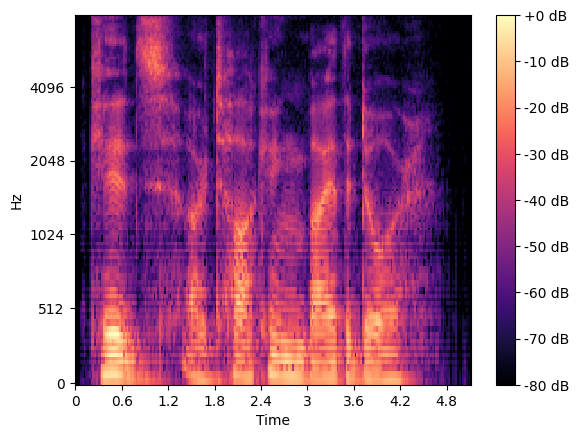

In [193]:
# What the network will see
# plt.figure().set_figwidth(12)
librosa.display.specshow(
    S_dB, x_axis="time",
    y_axis="mel",
    sr=SAMPLING_RATE,
    fmax=FMAX
)
plt.colorbar(format='%+2.0f dB')

In [194]:
S_dB.shape

(128, 221)

In [ ]:
# Suppose to play the audio file
from IPython.display import Audio
Audio(y, rate=audio_file_sr)

In [18]:
# Build mel-spectrogram extraction pipeline

def extract_mel_spectrogram(audio_file_list, sampling_rate=22050, fmax=8000, trim_threshold=30, n_fft=512, hop_length=256, max_duration=3.0):
    """
    Mel-spectrogram extraction pipeline.
    Extracts mel-spectrogram from an audio file list.
    Lecture refs:
     - from the lecture https://drive.google.com/drive/folders/1c26dPvQlfTps_WhIezzPagY1aKZySWe9
    """

    # Calculate exactly how many samples represent target duration
    target_samples = int(max_duration * sampling_rate)
    spects = []

    for audio_file in audio_file_list:
        # 1. load audio file
        y, audio_file_sr = librosa.load(audio_file, sr=sampling_rate, mono=True)

        # 2. trim silence - set thersholds TODO: optimize
        y, _ = librosa.effects.trim(y, top_db=trim_threshold) # Removes leading AND trailing silence

        # 2.5 FIX LENGTH: Pad with zeros
        y = librosa.util.fix_length(y, size=target_samples)

        # 3. extract mel-spectrogram
        S = librosa.feature.melspectrogram(
            y=y, # Audio signal
            sr=sampling_rate, # Sampling rate - pinned
            S=None, # from the lecture
            n_fft=n_fft, # window duration = 512/SAMPLING_RATE
            hop_length=hop_length, # sliding window = n_fft/2 for a perfect slide
            power=2, # from the lecture
            n_mels=128, # number of mel bands - standard
            fmin=50, # Filter out low-frequency
            fmax=fmax # Nyquist law: int(SAMPLING_RATE/2)
        )
        # Matrix of size (n_mels) X (time_steps)

        # 4. convert to log-mel (dB) - data for model training
        # Note: ref=np.max normalizes to 0dB TODO: optimize
        S_dB = librosa.power_to_db(S, ref=1.0)

        # Expand to account for the color channel
        S_dB = np.expand_dims(S_dB, axis=0)

        spects.append(S_dB)
    return spects

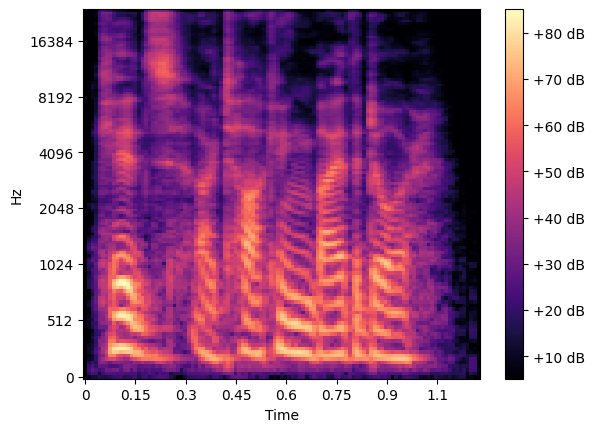

In [ ]:
"""
The longer way to extract mel-spectrogram.
Compute in order:
1. short-time Fourier transform (stft)
2. extract magnitude and phase of the signal
3. convert amplitude (only) to mel-scale
4. convert amplitude to DB
"""

sgram = librosa.stft(y)
sgram_mag, _ = librosa.magphase(sgram)
mel_scale_sgram = librosa.feature.melspectrogram(S=sgram_mag, sr=48000)
mel_sgram = librosa.amplitude_to_db(mel_scale_sgram, ref=np.min)
librosa.display.specshow(mel_sgram, sr=48000, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')

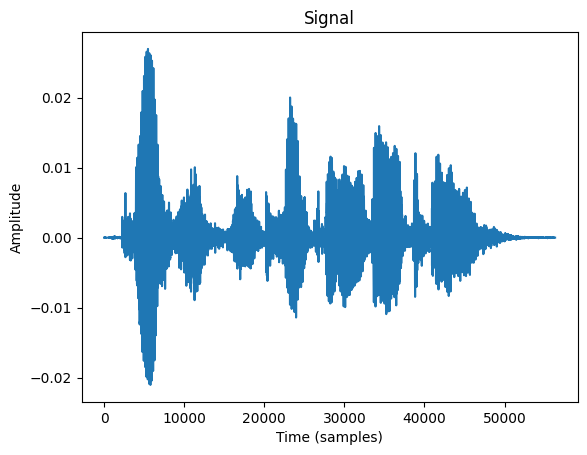

In [ ]:
"""
Visualize audio signal.
"""

plt.plot(y);
plt.title('Signal');
plt.xlabel('Time (samples)');
plt.ylabel('Amplitude');

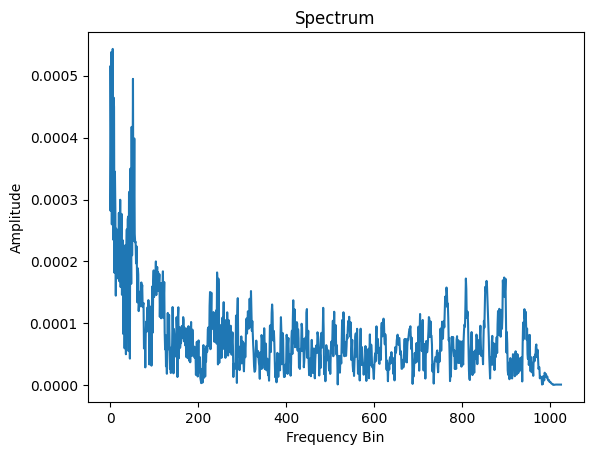

In [ ]:
"""
Apply FFT on the raw signal.
"""

n_fft = 2048
ft = np.abs(librosa.stft(y[:n_fft], hop_length = n_fft+1))
plt.plot(ft);
plt.title('Spectrum');
plt.xlabel('Frequency Bin');
plt.ylabel('Amplitude');

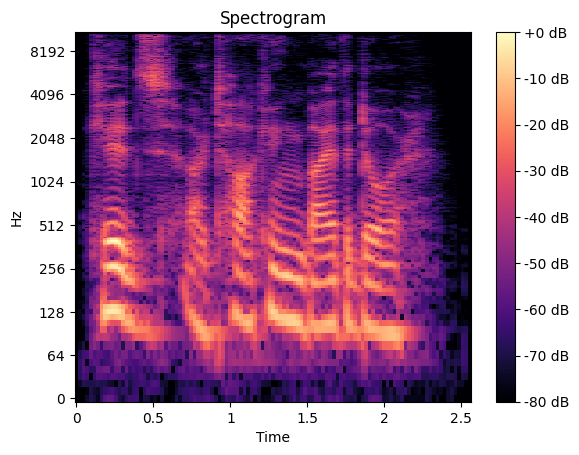

In [ ]:
"""
Display spectrogram only!
Spectrogram: a bunch of FFTs
"""

spec = np.abs(sgram)
spec = librosa.amplitude_to_db(spec, ref=np.max)
librosa.display.specshow(spec, sr=SAMPLING_RATE, x_axis='time', y_axis='log');
plt.colorbar(format='%+2.0f dB');
plt.title('Spectrogram');

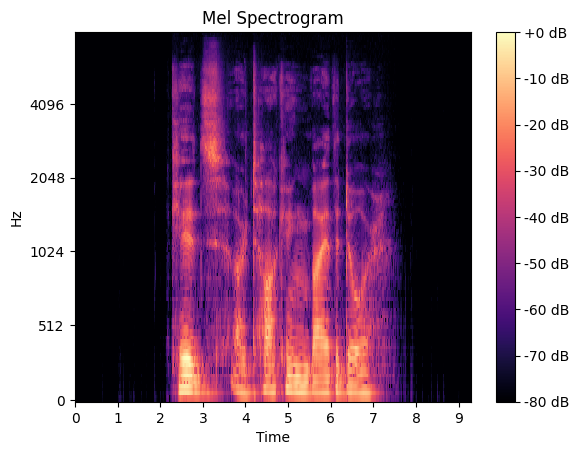

In [ ]:
"""
The direct way to go go Mel Scale - AKA the only method you need.
We perform a mathematical operation on frequencies to convert them to the mel scale. A mel spectrogram is a spectrogram where the frequencies are converted to the mel scale.
"""

SAMPLING_RATE = 48000
y, _ = librosa.load(audio_sample, sr=SAMPLING_RATE, mono=True)

mel_spect = librosa.feature.melspectrogram(y=y, sr=SAMPLING_RATE, n_fft=int(SAMPLING_RATE * 0.02), hop_length=int(SAMPLING_RATE*0.01))

# Convert to dB scale
mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

librosa.display.specshow(mel_spect_db, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram');
plt.colorbar(format='%+2.0f dB');

In [19]:
def audio_file_split(audio_paths):
    """
    Split the available audio files into training and testing sets.

    WHy do this?
    """

    train_files = []
    train_labels = []
    test_files = []
    test_labels = []

    for audio_file in audio_paths:
        # Extract the filename from the path
        filename = audio_file.split("/")[-1]

        parts = filename.replace(".wav", "").split("-")

        # Index 2 is emotion
        emotion_label = int(parts[2]) - 1

        # Index 6 is the Actor ID
        actor_id = int(parts[6])

        if actor_id <= 20:
            # Send to Training Data
            train_files.append(audio_file)
            train_labels.append(emotion_label)
        else:
            test_files.append(audio_file)
            test_labels.append(emotion_label)

    return train_files, train_labels, test_files, test_labels

In [20]:
train_files, train_labels, test_files, test_labels = audio_file_split(audio_paths)

In [21]:
train_mel_specs = extract_mel_spectrogram(audio_file_list=train_files)
test_mel_specs = extract_mel_spectrogram(audio_file_list=test_files)

In [22]:
len(train_mel_specs), len(train_labels), len(test_mel_specs), len(test_labels)

(1200, 1200, 240, 240)

---

# Dataset

In [23]:
import torch
from torch.utils.data import TensorDataset
import numpy as np
from sklearn.model_selection import train_test_split

In [24]:
# Prep for loaders
def create_dataset(mel_specs, labels):
    """
    Create dataset from mel-spectrograms and labels
    OUTPUT: (X,y) tensor pairs
    """

    X_array = np.array(mel_specs)
    y_array = np.array(labels)

    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    y_tensor = torch.tensor(y_array, dtype=torch.long)

    # normalize_signal: https://lefkippos.ds.unipi.gr/modules/document/file.php/AI_IIT107/AI%20-%20Multimodal%20AUDIO%20-%2002_%20Audio%20features.pdf
    mean = X_tensor.mean()
    std = X_tensor.std()
    X_tensor = (X_tensor - mean) / std
    dataset = TensorDataset(X_tensor, y_tensor)

    return dataset

In [25]:
train_ds = create_dataset(train_mel_specs, train_labels)
test_ds = create_dataset(test_mel_specs, test_labels)
len(train_ds), len(test_ds)

(1200, 240)

---

# Dataloaders

In [27]:
from torch.utils.data import DataLoader

In [28]:
BATCH_SIZE = 128
train_dl = DataLoader(dataset=train_ds, shuffle=True, batch_size=BATCH_SIZE)
test_dl = DataLoader(dataset=test_ds, shuffle=False, batch_size=BATCH_SIZE)

In [29]:
for batch_X, batch_y in train_dl:
    print(f"Batch X shape: {batch_X.shape}")
    print(f"Batch y shape: {batch_y.shape}")
    break

Batch X shape: torch.Size([128, 1, 128, 259])
Batch y shape: torch.Size([128])


In [30]:
for batch_X, batch_y in test_dl:
    print(f"Batch X shape: {batch_X.shape}")
    print(f"Batch y shape: {batch_y.shape}")
    break

Batch X shape: torch.Size([128, 1, 128, 259])
Batch y shape: torch.Size([128])


---

# Modeling baslines

Good starting point: https://github.com/tyiannak/deep_audio_features/blob/master/deep_audio_features/models/cnn.py

Note the 3 Linear layers at the end. Perhaps not what I need since I focus on encoding.

## CNN - baseline

In [3]:
import torch
import torch.nn as nn

class BaselineEmotionCNN(nn.Module):
    """ Checkout: https://ketanhdoshi.github.io/Audio-Classification/ """

    def __init__(self, num_classes=8):
        super(BaselineEmotionCNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier Head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5), # TODO: tweaking
            nn.Linear(128, num_classes) # 8 classes
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

### Train

In [48]:
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [45]:
# Batch training function

def train_loop(dataloader, model, optimizer, loss_fn):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    if torch.cuda.is_available():
        model.cuda()
    size = len(dataloader.dataset)
    model.train()

    epoch_loss = 0.0 # Track average loss

    for batch, (X, y) in enumerate(dataloader):
        # 1. Move to device!
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if batch % 6 == 0:
            loss_val = loss.item()
            current = batch * dataloader.batch_size + len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")

    return epoch_loss / len(dataloader)

In [7]:
# Batch test function

def test_loop(dataloader, model, loss_fn):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    if torch.cuda.is_available():
      model.cuda()

    size = len(dataloader.dataset)
    model.eval()
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return 100*correct, test_loss

In [46]:
# MOdel train function

def train_model(epochs, train_dl, test_dl, model, optimizer, loss_fn, acc_thr=45):

    # New tricks, this reduces LR based on a metric
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.01, patience=5)

    for e in range(epochs):
        print(f"Epoch {e+1}\n-------------------------------")
        epoch_loss = train_loop(train_dl, model, optimizer, loss_fn)
        print(f"Epoch loss: {epoch_loss}")
        curr_acc, _ = test_loop(test_dl, model, loss_fn)
        print(f"Test accuracy: {curr_acc}")
        scheduler.step(epoch_loss)
        print("-------------------------------")
        if curr_acc >= acc_thr:
            break

In [93]:
cnn_baseline = BaselineEmotionCNN(num_classes=len(set(emotion_labels)))
learning_rate = 1e-4
bs = 128
optimizer = torch.optim.Adam(params=cnn_baseline.parameters(), lr=learning_rate, weight_decay=1e-2)
loss_fn = nn.CrossEntropyLoss()
epochs = 35

train_model(epochs, train_dl, test_dl, cnn_baseline, optimizer, loss_fn, acc_thr=47)

Epoch 1
-------------------------------
loss: 2.109991  [  128/ 1200]
loss: 1.986534  [  896/ 1200]
Epoch loss: 2.0337685108184815
Test Error: 
 Accuracy: 22.1%, Avg loss: 2.068772 

Test accuracy: 22.083333333333332
-------------------------------
Epoch 2
-------------------------------
loss: 2.004681  [  128/ 1200]
loss: 1.939929  [  896/ 1200]
Epoch loss: 1.943601095676422
Test Error: 
 Accuracy: 19.2%, Avg loss: 2.037909 

Test accuracy: 19.166666666666668
-------------------------------
Epoch 3
-------------------------------
loss: 1.913324  [  128/ 1200]
loss: 1.947536  [  896/ 1200]
Epoch loss: 1.8992638111114502
Test Error: 
 Accuracy: 16.7%, Avg loss: 1.951746 

Test accuracy: 16.666666666666664
-------------------------------
Epoch 4
-------------------------------
loss: 1.878855  [  128/ 1200]
loss: 1.859587  [  896/ 1200]
Epoch loss: 1.8620397448539734
Test Error: 
 Accuracy: 24.2%, Avg loss: 1.868532 

Test accuracy: 24.166666666666668
-------------------------------
Epoch

In [77]:
accuracy, _ = test_loop(test_dl, cnn_baseline, loss_fn)

Test Error: 
 Accuracy: 50.8%, Avg loss: 1.334548 



## Model saving

In [101]:
# Save model function
from google.colab import drive

def save_model(model, model_name):
    drive.mount("/content/drive")
    save_path = f"/content/drive/MyDrive/notebooks/saved_models/"
    torch.save(model.state_dict(), save_path + model_name)

In [ ]:
save_model(cnn_baseline, "cnn_baseline_acc50.pt")

Mounted at /content/drive


## Transfer learning: ResNet18

Does transfer learning work better in this case?

In [50]:
import torch
import torch.nn as nn
import torchvision.models as models

# 1. Load the pre-trained model
resnet18 = models.resnet18(weights="IMAGENET1K_V1")

# 2. Modify the first convolutional layer to accept 1-channel Mel-spectrograms
original_conv1 = resnet18.conv1
resnet18.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
with torch.no_grad():
    # Average the RGB weights to create a 1-channel weight
    resnet18.conv1.weight.copy_(torch.mean(original_conv1.weight, dim=1, keepdim=True))

# 3. Modify the final classification layer for 8 RAVDESS emotions
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 8)

In [51]:
accuracy, _ = test_loop(test_dl, resnet18, loss_fn)

Test Error: 
 Accuracy: 10.8%, Avg loss: 2.204417 



In [52]:
learning_rate = 1e-3
bs = 64
optimizer = torch.optim.Adam(params=resnet18.parameters(), lr=learning_rate, weight_decay=1e-3)
loss_fn = nn.CrossEntropyLoss()
epochs = 30

train_model(epochs, train_dl, test_dl, resnet18, optimizer, loss_fn, acc_thr=90)

Epoch 1
-------------------------------
loss: 2.298254  [  128/ 1200]
loss: 1.118659  [  896/ 1200]
Epoch loss: 1.4609287619590758
Test Error: 
 Accuracy: 18.8%, Avg loss: 6.510203 

Test accuracy: 18.75
-------------------------------
Epoch 2
-------------------------------
loss: 0.686700  [  128/ 1200]
loss: 0.821902  [  896/ 1200]
Epoch loss: 0.7211276292800903
Test Error: 
 Accuracy: 25.8%, Avg loss: 3.919155 

Test accuracy: 25.833333333333336
-------------------------------
Epoch 3
-------------------------------
loss: 0.464840  [  128/ 1200]
loss: 0.296207  [  896/ 1200]
Epoch loss: 0.4061778783798218
Test Error: 
 Accuracy: 43.3%, Avg loss: 2.940252 

Test accuracy: 43.333333333333336
-------------------------------
Epoch 4
-------------------------------
loss: 0.165389  [  128/ 1200]
loss: 0.119363  [  896/ 1200]
Epoch loss: 0.17791084721684455
Test Error: 
 Accuracy: 43.3%, Avg loss: 3.256407 

Test accuracy: 43.333333333333336
-------------------------------
Epoch 5
--------

In [53]:
accuracy, _ = test_loop(test_dl, resnet18, loss_fn)

Test Error: 
 Accuracy: 64.2%, Avg loss: 1.250419 



In [174]:
save_model(resnet18, "resnet18_acc63")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# SupConArchitecture

Moving on to Supervised Contrastive Learning.

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## Emotion Feature Extractor base class

THis is the base of the network which we're going to re-use.

In [34]:
class EmotionFeatureExtractorBase(nn.Module):
    """
    Core CNN to extract spatial features from Mel-Spectrograms.
    Outputs a flat 256-dimensional feature vector.
    """
    def __init__(self):
        super(EmotionFeatureExtractorBase, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_pool(x)
        x = self.flatten(x)
        return x # Output shape: (batch_size, 256)


---

## SupCon base - stage 1

In [35]:
class SupConStage1(nn.Module):
    """ Model B (Stage 1): Encoder + MLP Projection Head for SupCon Loss. """
    def __init__(self, projection_dim=128):
        super(SupConStage1, self).__init__()
        self.encoder = EmotionFeatureExtractorBase()

        # MLP Projection Head
        self.projection_head = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        embeddings = self.projection_head(features)

        # L2 Normalization, required for Contrastive Loss
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings

Turns out implementing supervised contrastive loss from scratch is a pain. Luckily, I found this https://kevinmusgrave.github.io/pytorch-metric-learning/

In [36]:
%%capture
!pip install pytorch-metric-learning

### Training

In [96]:
# Stage 1 embeddings layers trainings

import torch
from pytorch_metric_learning import losses

supcon_stage1 = SupConStage1(projection_dim=128)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
supcon_stage1 = supcon_stage1.to(device)

optimizer_stage1 = torch.optim.Adam(params=supcon_stage1.parameters(), lr=1e-3, weight_decay=1e-4)

# USe SupCon Loss
loss_fn_supcon = losses.SupConLoss(temperature=0.1)

epochs_stage1 = 30

print("--- Starting Stage 1: SupCon Clustering ---")
for epoch in range(epochs_stage1):
    supcon_stage1.train()
    running_loss = 0.0

    for batch_x, batch_y in train_dl:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer_stage1.zero_grad()

        # Output is L2-normalized embeddings, NOT class logits
        embeddings = supcon_stage1(batch_x)

        # Calculate contrastive loss based on labels
        loss = loss_fn_supcon(embeddings, batch_y)

        loss.backward()
        optimizer_stage1.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_dl)
    print(f"Epoch {epoch+1}/{epochs_stage1} - SupCon Loss: {avg_loss:.4f}")

--- Starting Stage 1: SupCon Clustering ---
Epoch 1/30 - SupCon Loss: 4.6734
Epoch 2/30 - SupCon Loss: 4.6274
Epoch 3/30 - SupCon Loss: 4.6047
Epoch 4/30 - SupCon Loss: 4.5808
Epoch 5/30 - SupCon Loss: 4.5600
Epoch 6/30 - SupCon Loss: 4.5576
Epoch 7/30 - SupCon Loss: 4.5262
Epoch 8/30 - SupCon Loss: 4.4827
Epoch 9/30 - SupCon Loss: 4.4677
Epoch 10/30 - SupCon Loss: 4.4412
Epoch 11/30 - SupCon Loss: 4.4159
Epoch 12/30 - SupCon Loss: 4.4107
Epoch 13/30 - SupCon Loss: 4.3496
Epoch 14/30 - SupCon Loss: 4.3766
Epoch 15/30 - SupCon Loss: 4.3022
Epoch 16/30 - SupCon Loss: 4.3269
Epoch 17/30 - SupCon Loss: 4.3176
Epoch 18/30 - SupCon Loss: 4.2343
Epoch 19/30 - SupCon Loss: 4.2273
Epoch 20/30 - SupCon Loss: 4.1906
Epoch 21/30 - SupCon Loss: 4.1162
Epoch 22/30 - SupCon Loss: 4.0857
Epoch 23/30 - SupCon Loss: 4.0994
Epoch 24/30 - SupCon Loss: 4.0594
Epoch 25/30 - SupCon Loss: 4.0048
Epoch 26/30 - SupCon Loss: 4.1359
Epoch 27/30 - SupCon Loss: 4.0792
Epoch 28/30 - SupCon Loss: 3.9405
Epoch 29/30 -

## SupCon classifier - stage 2

In [36]:
class SupConStage2(nn.Module):
    """ Model B (Stage 2): Frozen Encoder + Linear Classifier. """
    def __init__(self, trained_encoder, num_classes=8):
        super(SupConStage2, self).__init__()

        # Pass trained encoder from Stage 1
        self.encoder = trained_encoder

        # Freeze encoder weights
        for param in self.encoder.parameters():
            param.requires_grad = False

        # Linear classifier
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        # Disable gradient tracking for the encoder to save memory/compute
        with torch.no_grad():
            features = self.encoder(x)

        return self.classifier(features)

### Training

In [98]:
print("--- Starting Stage 2: Linear Probing ---")

# Decouple CNN from Stage 1
trained_encoder = supcon_stage1.encoder

# Init Model B - Stage 2
supcon_stage2 = SupConStage2(trained_encoder=trained_encoder, num_classes=len(set(emotion_labels)))
supcon_stage2 = supcon_stage2.to(device)

# 3. Setup optimizer ONLY for the new classifier head
optimizer_stage2 = torch.optim.Adam(params=supcon_stage2.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

loss_fn_ce = torch.nn.CrossEntropyLoss()
epochs_stage2 = 30

# 4. Eval final accuracy
train_model(epochs_stage2, train_dl, test_dl, supcon_stage2, optimizer_stage2, loss_fn_ce, acc_thr=50)

--- Starting Stage 2: Linear Probing ---
Epoch 1
-------------------------------
loss: 2.090468  [  128/ 1200]
loss: 1.993055  [  896/ 1200]
Epoch loss: 2.011804437637329
Test Error: 
 Accuracy: 29.2%, Avg loss: 1.948362 

Test accuracy: 29.166666666666668
-------------------------------
Epoch 2
-------------------------------
loss: 1.955559  [  128/ 1200]
loss: 1.876599  [  896/ 1200]
Epoch loss: 1.9111636638641358
Test Error: 
 Accuracy: 42.9%, Avg loss: 1.849449 

Test accuracy: 42.916666666666664
-------------------------------
Epoch 3
-------------------------------
loss: 1.855994  [  128/ 1200]
loss: 1.821688  [  896/ 1200]
Epoch loss: 1.8187148928642274
Test Error: 
 Accuracy: 39.6%, Avg loss: 1.774159 

Test accuracy: 39.58333333333333
-------------------------------
Epoch 4
-------------------------------
loss: 1.776253  [  128/ 1200]
loss: 1.773531  [  896/ 1200]
Epoch loss: 1.7522668838500977
Test Error: 
 Accuracy: 42.9%, Avg loss: 1.714419 

Test accuracy: 42.9166666666666

In [102]:
save_model(supcon_stage2, "supcon_stage2_acc45.pt")

Mounted at /content/drive


We're getting similar results to baseline CNN and not anywhere close to the trainsfer learning.

# Adding augmentations - `SpecAugment`

We implement a class to apply augmentations to the training data to force the supcon model to learn actual emotion pitches.

In [37]:
import torch
import torch.nn as nn
import random

# Drop to GPU
class SpecAugment(nn.Module):
    """
    Applies Time and Frequency Masking to batches of Mel-Spectrograms.
    Expects input shape: (Batch, Channels, Freq, Time) -> (B, 1, 128, T)
    """
    def __init__(self, freq_mask_param=15, time_mask_param=30, num_freq_masks=2, num_time_masks=2):
        super(SpecAugment, self).__init__()
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks

    def forward(self, x):
        # Only apply augmentation during training
        if not self.training:
            return x

        # Clone the tensor to prevent accidents again!
        x_aug = x.clone()
        B, C, F, T = x_aug.shape

        # masks each spectrogram in the batch - this will parts of the image
        for i in range(B):
            # 1. Frequency Masking
            for _ in range(self.num_freq_masks):
                f = random.randint(0, self.freq_mask_param)
                # Check out of bounds
                # Pick a random freq to mask
                f0 = random.randint(0, F - f)
                # Fill with mean of  standardized
                x_aug[i, :, f0:f0+f, :] = 0.0

            # 2. Time Masking
            for _ in range(self.num_time_masks):
                t = random.randint(0, self.time_mask_param)
                # Check out of bounds
                # Pick random time to mask
                t0 = random.randint(0, T - t)
                # Fill the masked time band with 0.0
                x_aug[i, :, :, t0:t0+t] = 0.0

        return x_aug

## Training - stage 1

Drop `SpecAugment` into sttage 1 training loop.

In [103]:
# Set devie again because I'm running on Colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Setup Model + Augmenter
supcon_stage1 = SupConStage1(projection_dim=128).to(device)

# Initialize Augmenter AND load to device
augmenter = SpecAugment(freq_mask_param=15, time_mask_param=30).to(device)

learning_rate = 1e-3
optimizer_stage1 = torch.optim.Adam(params=supcon_stage1.parameters(), lr=learning_rate, weight_decay=1e-4)
loss_fn_supcon = losses.SupConLoss(temperature=0.1)
epochs_stage1 = 100

print("--- Starting Stage 1: SupCon Clustering + SpecAugment ---")

for epoch in range(epochs_stage1):
    supcon_stage1.train()
    augmenter.train() # Double check again!
    running_loss = 0.0

    for batch_x, batch_y in train_dl:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        view1 = augmenter(batch_x)
        view2 = augmenter(batch_x)

        # Stack together -> Doubles batch size: 256
        combined_x = torch.cat([view1, view2], dim=0)
        combined_y = torch.cat([batch_y, batch_y], dim=0)

        optimizer_stage1.zero_grad()

        # 3. Pass the AUGMENTED data into the encoder
        embeddings = supcon_stage1(combined_x)

        # Calculate contrastive loss
        loss = loss_fn_supcon(embeddings, combined_y)

        loss.backward()
        optimizer_stage1.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_dl)

    # Batch epoch stats
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs_stage1} - SupCon Loss: {avg_loss:.4f}")

--- Starting Stage 1: SupCon Clustering + SpecAugment ---
Epoch 10/100 - SupCon Loss: 5.2564
Epoch 20/100 - SupCon Loss: 5.0944
Epoch 30/100 - SupCon Loss: 5.0484
Epoch 40/100 - SupCon Loss: 4.9674
Epoch 50/100 - SupCon Loss: 4.8103
Epoch 60/100 - SupCon Loss: 4.5603
Epoch 70/100 - SupCon Loss: 4.4515
Epoch 80/100 - SupCon Loss: 4.3404
Epoch 90/100 - SupCon Loss: 4.0299
Epoch 100/100 - SupCon Loss: 3.9263


## Training - stage 2

Re-use the encoder from above and plug stage 2 head on top.

In [108]:
print("--- Starting Stage 2: Linear Probing ---")

# Decouple CNN from Stage 1
trained_encoder = supcon_stage1.encoder

# Init Model B - Stage 2
supcon_stage2 = SupConStage2(trained_encoder=trained_encoder, num_classes=len(set(emotion_labels)))
supcon_stage2 = supcon_stage2.to(device)

# 3. Setup optimizer ONLY for the new classifier head
optimizer_stage2 = torch.optim.Adam(params=supcon_stage2.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

loss_fn_ce = torch.nn.CrossEntropyLoss()
epochs_stage2 = 30

# Bump accuracy threshold
train_model(epochs_stage2, train_dl, test_dl, supcon_stage2, optimizer_stage2, loss_fn_ce, acc_thr=55)

--- Starting Stage 2: Linear Probing ---
Epoch 1
-------------------------------
loss: 2.091351  [  128/ 1200]
loss: 1.960160  [  896/ 1200]
Epoch loss: 1.9854170322418212
Test Error: 
 Accuracy: 33.3%, Avg loss: 1.931196 

Test accuracy: 33.33333333333333
-------------------------------
Epoch 2
-------------------------------
loss: 1.860953  [  128/ 1200]
loss: 1.870568  [  896/ 1200]
Epoch loss: 1.8803999304771424
Test Error: 
 Accuracy: 40.0%, Avg loss: 1.844972 

Test accuracy: 40.0
-------------------------------
Epoch 3
-------------------------------
loss: 1.867047  [  128/ 1200]
loss: 1.790547  [  896/ 1200]
Epoch loss: 1.7870002865791321
Test Error: 
 Accuracy: 41.7%, Avg loss: 1.774902 

Test accuracy: 41.66666666666667
-------------------------------
Epoch 4
-------------------------------
loss: 1.748060  [  128/ 1200]
loss: 1.723878  [  896/ 1200]
Epoch loss: 1.718312931060791
Test Error: 
 Accuracy: 40.4%, Avg loss: 1.714240 

Test accuracy: 40.416666666666664
------------

In [109]:
accuracy, _ = test_loop(test_dl, supcon_stage2, loss_fn_ce)

Test Error: 
 Accuracy: 50.8%, Avg loss: 1.246685 



In [ ]:
save_model(supcon_stage2, "supcon_stage2_acc53.pt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Fine-tuning

Unfreeze the whole network and train for a a genetle amount of epochs.

In [125]:
# Load best supcon_stage2 model from google drive - A.K.A. The Precious
supcon_stage2 = SupConStage2(trained_encoder=trained_encoder, num_classes=len(set(emotion_labels)))
supcon_stage2.load_state_dict(torch.load("/content/drive/MyDrive/notebooks/saved_models/supcon_stage2_acc53.pt"))
supcon_stage2 = supcon_stage2.to(device)

In [126]:
print("--- Starting Stage 3: End-to-End Fine-Tuning ---")

# 1. Unfreeze the heavily trained encoder
for param in supcon_stage2.encoder.parameters():
    param.requires_grad = True

# 2. Setup optimizer for the ENTIRE model (Encoder + Classifier)
# CRITICAL: The learning rate must be tiny (1e-5) so we don't destroy the clusters!
optimizer_fine_tune = torch.optim.Adam(params=supcon_stage2.parameters(), lr=1e-5, weight_decay=1e-4)

# optimizer_fine_tune = torch.optim.Adam([
#     {"params": supcon_stage2.encoder.parameters(), "lr": 1e-4},
#     {"params": supcon_stage2.classifier.parameters(), "lr": 1e-3}
# ], weight_decay=1e-4)

# 3. Train
train_model(30, train_dl, test_dl, supcon_stage2, optimizer_fine_tune, loss_fn_ce, acc_thr=60)

--- Starting Stage 3: End-to-End Fine-Tuning ---
Epoch 1
-------------------------------
loss: 1.150069  [  128/ 1200]
loss: 1.120010  [  896/ 1200]
Epoch loss: 1.126132345199585
Test Error: 
 Accuracy: 53.8%, Avg loss: 1.280983 

Test accuracy: 53.75
-------------------------------
Epoch 2
-------------------------------
loss: 1.105812  [  128/ 1200]
loss: 1.068324  [  896/ 1200]
Epoch loss: 1.1279969215393066
Test Error: 
 Accuracy: 54.2%, Avg loss: 1.280936 

Test accuracy: 54.166666666666664
-------------------------------
Epoch 3
-------------------------------
loss: 1.131282  [  128/ 1200]
loss: 1.196933  [  896/ 1200]
Epoch loss: 1.1297878265380858
Test Error: 
 Accuracy: 53.8%, Avg loss: 1.281313 

Test accuracy: 53.75
-------------------------------
Epoch 4
-------------------------------
loss: 1.116176  [  128/ 1200]
loss: 1.158609  [  896/ 1200]
Epoch loss: 1.135619330406189
Test Error: 
 Accuracy: 53.8%, Avg loss: 1.281168 

Test accuracy: 53.75
----------------------------

In [ ]:
accuracy, _ = test_loop(test_dl, supcon_stage2, loss_fn_ce)

Test Error: 
 Accuracy: 60.0%, Avg loss: 1.122364 



In [ ]:
# Save the model
save_model(supcon_stage2, "supcon_stage_ft_acc60.pt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Evaluation results

In [5]:
# Define model load function

from google.colab import drive

def load_model(path, ModelClass):
    """ Loads the parameters from a saved model. """
    drive.mount("/content/drive")
    model = ModelClass()
    model.load_state_dict(torch.load(path))
    return model

## Load SOTA models
Load best model in order.

In [31]:
# CNN baseline SOTA
p = "/content/drive/MyDrive/notebooks/saved_models/cnn_baseline_acc50.pt"
baseline_model = load_model(p, BaselineEmotionCNN)
loss_fn = nn.CrossEntropyLoss()
baseline_model.eval()
accuracy, _ = test_loop(test_dl, baseline_model, loss_fn)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Test Error: 
 Accuracy: 53.3%, Avg loss: 1.191933 



In [38]:
# SKIP - perhaps a data leak happened during traiing
import torchvision.models as models

resnet18 = models.resnet18()

# Apply architecture changes
resnet18.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 8)

# Load weights dict
p = "/content/drive/MyDrive/notebooks/saved_models/resnet18"
state_dict = torch.load(p)

# Apply
resnet18.load_state_dict(state_dict)

resnet18.eval()

loss_fn = nn.CrossEntropyLoss()
accuracy, _ = test_loop(test_dl, resnet18, loss_fn)

Test Error: 
 Accuracy: 95.0%, Avg loss: 0.146904 



In [39]:
# Load SupCon stage 2 SOTA
blank_encoder = EmotionFeatureExtractorBase()

supcon_stage2_53 = SupConStage2(trained_encoder=blank_encoder, num_classes=8)

p = "/content/drive/MyDrive/notebooks/saved_models/supcon_stage2_acc53.pt"
supcon_stage2_53.load_state_dict(torch.load(p))
supcon_stage2_53.eval()
loss_fn = nn.CrossEntropyLoss()
supcon_stage2_53.eval()
accuracy, _ = test_loop(test_dl, supcon_stage2_53, loss_fn)

Test Error: 
 Accuracy: 53.8%, Avg loss: 1.289050 



In [40]:
# Load SupCon stage 2 FT SOTA

blank_encoder = EmotionFeatureExtractorBase()

supcon_stage2_ft = SupConStage2(trained_encoder=blank_encoder, num_classes=8)

p = "/content/drive/MyDrive/notebooks/saved_models/supcon_stage_ft_acc60.pt"
supcon_stage2_ft.load_state_dict(torch.load(p))
supcon_stage2_ft.eval()
loss_fn = nn.CrossEntropyLoss()
supcon_stage2_ft.eval()
accuracy, _ = test_loop(test_dl, supcon_stage2_ft, loss_fn)

Test Error: 
 Accuracy: 60.0%, Avg loss: 1.129924 



## Build evaluation pipeline

In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [60]:
# Automate geting model predictions
def get_predictions(model, data_loader, device):
    """
    Runs the test dataset through the model and returns all true labels and predictions.
    """
    model.eval() # Double check
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)

            # Get the index of the highest probability
            preds = torch.argmax(outputs, dim=1)

            # Make sure we get all preds inside the batch!
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())

    return np.array(all_labels), np.array(all_preds)

In [55]:
def evaluate_with_noise(model, data_loader, device, noise_std):
    """
    Evaluates the model on the test set after injecting Gaussian noise.
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            # Inject Gaussian noise based on std. dev.
            if noise_std > 0.0:
                noise = torch.randn_like(batch_x) * noise_std
                batch_x = batch_x + noise

            outputs = model(batch_x)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

    return (correct / total) * 100.0

In [56]:
def plot_confusion_matrices(y_true, predictions_dict, class_names):
    """
    Plots confusion matrices for all models in a 2x2 grid.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()

    for idx, (model_name, y_pred) in enumerate(predictions_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                    xticklabels=class_names, yticklabels=class_names)
        axes[idx].set_title(f"{model_name}")
        axes[idx].set_ylabel("True Emotion")
        axes[idx].set_xlabel("Predicted Emotion")

    plt.tight_layout()
    plt.show()

In [57]:
def plot_robustness_curve(noise_levels, results_dict):
    """
    Plots the accuracy degradation of all models as noise increases.
    """
    plt.figure(figsize=(12, 7))
    markers = ["o", "s", "^", "D"]
    colors = ["blue", "green", "red", "purple"]

    for idx, (model_name, accs) in enumerate(results_dict.items()):
        plt.plot(noise_levels, accs, marker=markers[idx], linestyle="-",
                 color=colors[idx], label=model_name, linewidth=2)

    plt.title("Model Robustness Under Gaussian Noise", fontsize=14)
    plt.xlabel("Gaussian Noise Standard Deviation", fontsize=12)
    plt.ylabel("Test Accuracy (%)", fontsize=12)
    plt.xticks(noise_levels)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

PART 1: STANDARD EVALUATION (NO NOISE)
Extracting clean predictions for CNN Baseline...
Extracting clean predictions for ResNet18...
Extracting clean predictions for SupCon Frozen...
Extracting clean predictions for SupCon Fine-Tuned...

CNN BASELINE CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Neutral       0.43      0.38      0.40        16
        Calm       0.50      0.69      0.58        32
       Happy       0.23      0.16      0.19        32
         Sad       0.25      0.22      0.23        32
       Angry       0.73      0.84      0.78        32
     Fearful       0.61      0.34      0.44        32
     Disgust       0.56      0.75      0.64        32
   Surprised       0.76      0.81      0.79        32

    accuracy                           0.53       240
   macro avg       0.51      0.52      0.51       240
weighted avg       0.51      0.53      0.51       240


RESNET18 CLASSIFICATION REPORT
              precision    recall  f1-score 

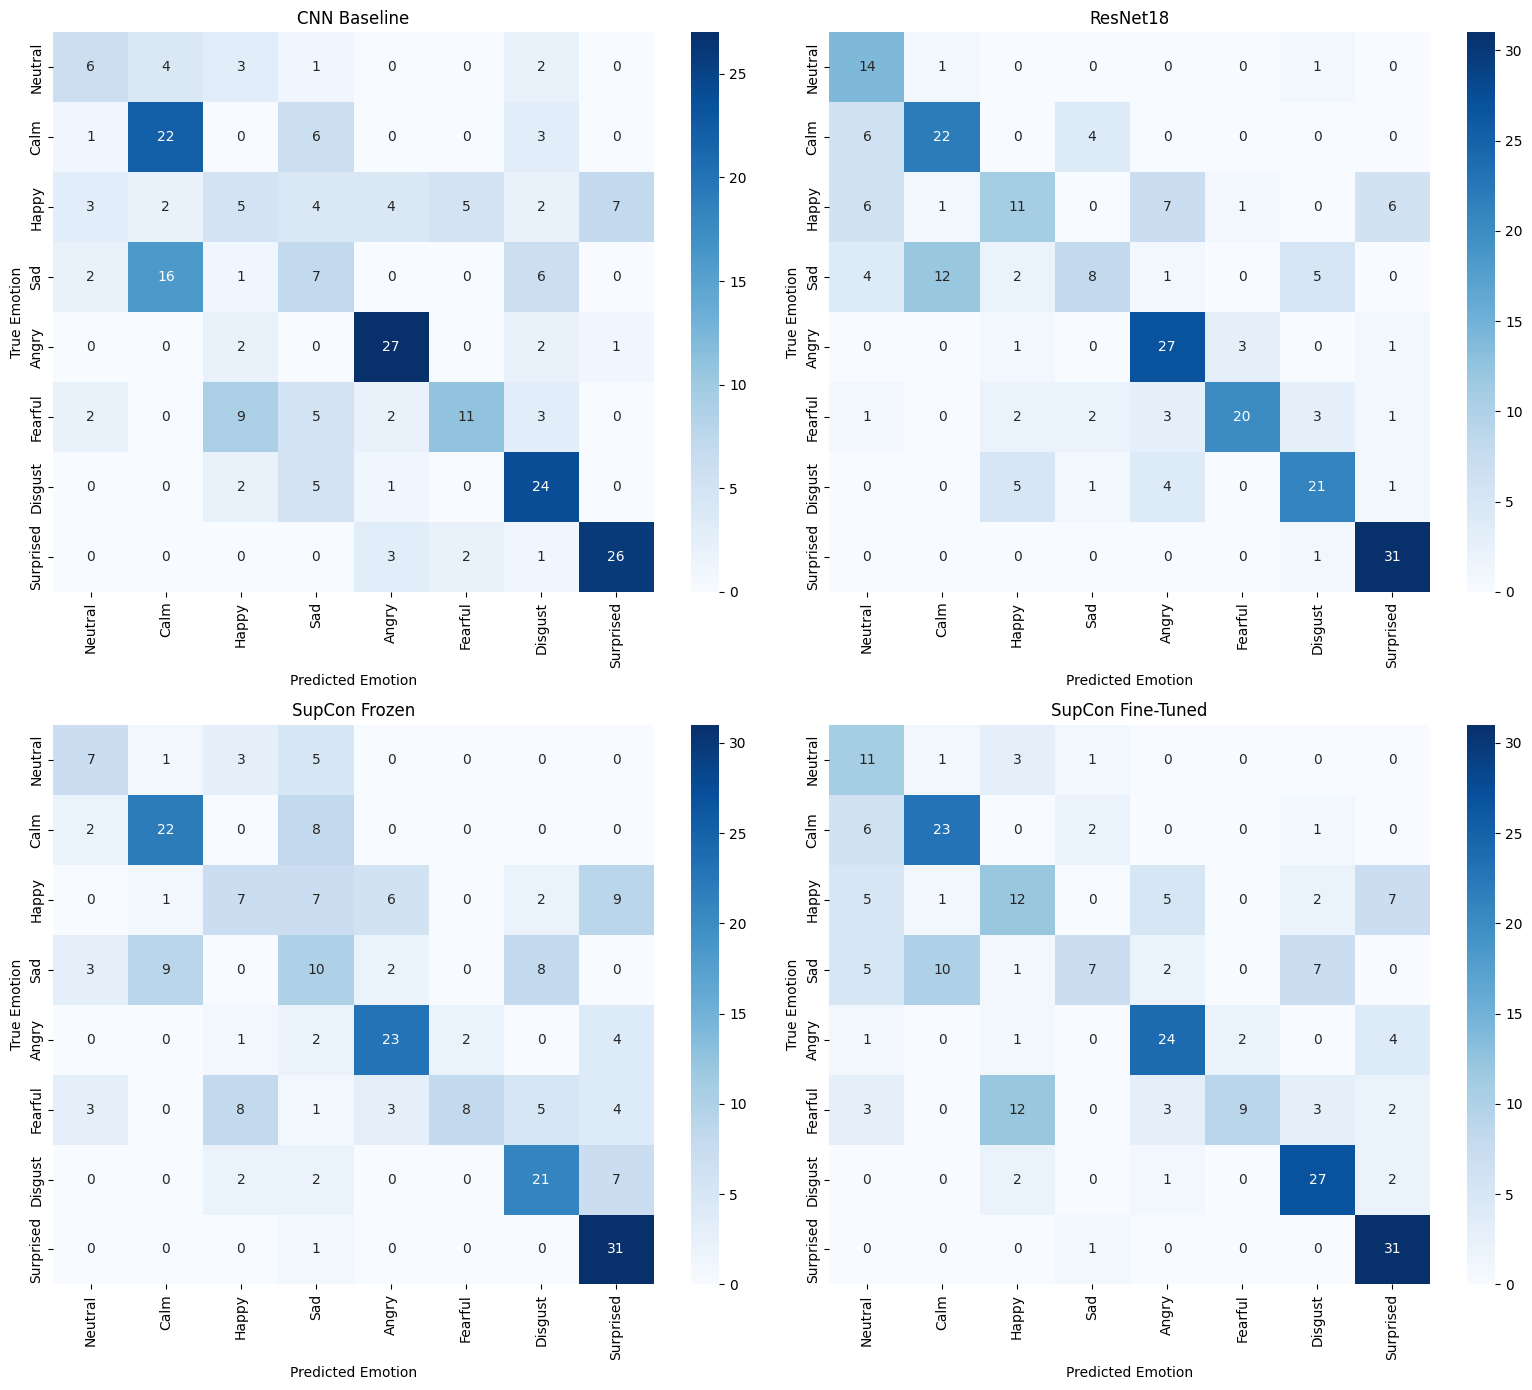

In [65]:
# ==========================================
# RUN THE EVALUATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

emotion_classes = ["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised"]

# Bundle all loaded models
models_dict = {
    "CNN Baseline": baseline_model.to(device),
    "ResNet18": resnet18.to(device),
    "SupCon Frozen": supcon_stage2_53.to(device),
    "SupCon Fine-Tuned": supcon_stage2_ft.to(device)
}

print("="*50)
print("PART 1: STANDARD EVALUATION (NO NOISE)")
print("="*50)

predictions_dict = {}
y_true = None

# Models perds - clean
for name, model in models_dict.items():
    print(f"Extracting clean predictions for {name}...")
    y_true_temp, y_pred = get_predictions(model, test_dl, device)
    predictions_dict[name] = y_pred

    # We only need to store the true labels once
    if y_true is None:
        y_true = y_true_temp

# Print Classification Reports
for name, y_pred in predictions_dict.items():
    print("\n" + "="*50)
    print(f"{name.upper()} CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(y_true, y_pred, target_names=emotion_classes))

# Plot 2x2 Confusion Matrices
plot_confusion_matrices(y_true, predictions_dict, emotion_classes)


PART 2: ROBUSTNESS TESTING (GAUSSIAN NOISE)

Testing with Noise STD: 0.0...
  -> CNN Baseline: 53.33%
  -> ResNet18: 64.17%
  -> SupCon Frozen: 53.75%
  -> SupCon Fine-Tuned: 60.00%

Testing with Noise STD: 0.05...
  -> CNN Baseline: 50.42%
  -> ResNet18: 65.42%
  -> SupCon Frozen: 53.33%
  -> SupCon Fine-Tuned: 56.25%

Testing with Noise STD: 0.1...
  -> CNN Baseline: 49.58%
  -> ResNet18: 65.83%
  -> SupCon Frozen: 45.00%
  -> SupCon Fine-Tuned: 47.92%

Testing with Noise STD: 0.2...
  -> CNN Baseline: 25.83%
  -> ResNet18: 62.50%
  -> SupCon Frozen: 32.08%
  -> SupCon Fine-Tuned: 29.17%

Testing with Noise STD: 0.3...
  -> CNN Baseline: 17.50%
  -> ResNet18: 58.33%
  -> SupCon Frozen: 28.75%
  -> SupCon Fine-Tuned: 23.33%

Testing with Noise STD: 0.4...
  -> CNN Baseline: 13.75%
  -> ResNet18: 43.33%
  -> SupCon Frozen: 17.08%
  -> SupCon Fine-Tuned: 26.67%

Testing with Noise STD: 0.5...
  -> CNN Baseline: 13.33%
  -> ResNet18: 35.00%
  -> SupCon Frozen: 13.75%
  -> SupCon Fine-Tu

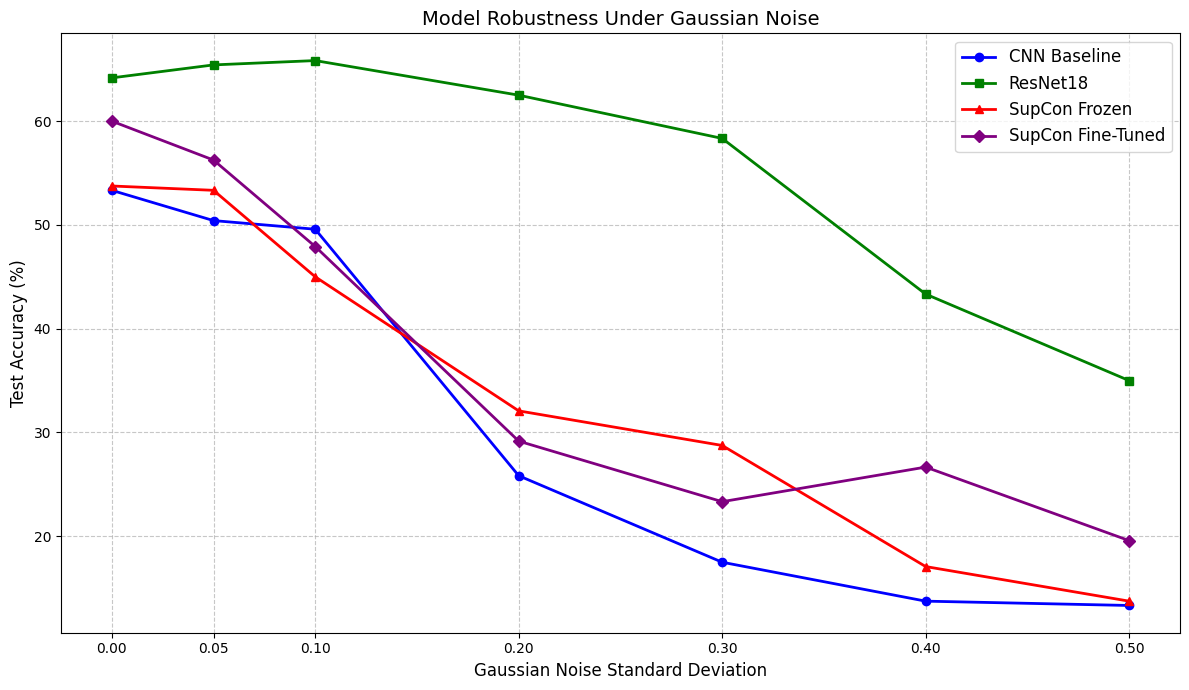


Evaluation complete!


In [64]:
# PART-2: Results under noisy conditions
### ----------- ###
print("\n" + "="*50)
print("PART 2: ROBUSTNESS TESTING (GAUSSIAN NOISE)")
print("="*50)

# Fine tuning for noise levels
noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
robustness_results = {name: [] for name in models_dict.keys()}

for std in noise_levels:
    print(f"\nTesting with Noise STD: {std}...")
    for name, model in models_dict.items():
        acc = evaluate_with_noise(model, test_dl, device, std)
        robustness_results[name].append(acc)
        print(f"  -> {name}: {acc:.2f}%")

# Plot the final line graph
plot_robustness_curve(noise_levels, robustness_results)
print("\nEvaluation complete!")